In [1]:
# =========================================
# Etape 1 - Chargement & Inspection
# =========================================
import pandas as pd
# ----- 1. Charger les datasets train et test -----
train = pd.read_csv("train.csv")  # Remplacer par le chemin réel
test = pd.read_csv("test.csv")
# ----- 2. Afficher un aperçu des données -----
print("----- Aperçu train -----")
print(train.head())
print("\n----- Aperçu test -----")
print(test.head())
# ----- 3. Vérifier la forme (nb lignes et colonnes) -----
print("\nTrain shape:", train.shape)
print("Test shape:", test.shape)
# ----- 4. Vérifier les types de données -----
print("\nTypes de données train:")
print(train.dtypes)
print("\nTypes de données test:")
print(test.dtypes)
# ----- 5. Identifier colonnes numériques vs catégorielles -----
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
print("\nColonnes numériques:", numerical_cols)
print("Colonnes catégorielles:", categorical_cols)
# ----- 6. Vérifier les valeurs uniques pour les colonnes importantes -----
for col in categorical_cols:
    print(f"\nColonne '{col}' - exemples de valeurs uniques:")
    print(train[col].value_counts(dropna=True).head(10))  # Top 10 valeurs
# ----- 7. Vérifier et nettoyer le format du prix -----
# Fonction pour nettoyer le prix (supprime les lettres, garde les chiffres)
def clean_prix(x):
    if isinstance(x, str):
        x = ''.join(filter(str.isdigit, x))
    try:
        return float(x)
    except:
        return None
# Nettoyage seulement si la colonne 'prix' existe
if 'prix' in train.columns:
    train['prix'] = train['prix'].apply(clean_prix)
    print("\nAprès nettoyage, aperçu du prix (train):")
    print(train['prix'].head())
if 'prix' in test.columns:
    test['prix'] = test['prix'].apply(clean_prix)
    print("\nAprès nettoyage, aperçu du prix (test):")
    print(test['prix'].head())
# ----- 8. Vérifier les devises (si colonne existe) -----
if 'devise' in train.columns:
    print("\nValeurs uniques de la colonne 'devise' (train):", train['devise'].unique())
    # Conversion possible EUR->MRU, USD->MRU si besoin
    # train.loc[train['devise']=='EUR', 'prix'] *= 42  # exemple 1 EUR = 42 MRU
    # train['devise'] = 'MRU'
# ----- 9. Statistiques de base -----
print("\nStatistiques de base des colonnes numériques (train):")
print(train.describe())
# ----- 10. Fin de l'étape 1 -----
print("\n=== Etape 1 terminée : Chargement & Inspection terminée ===")


----- Aperçu train -----
     id                                              titre       prix  \
0  1076                    منزل احذ اللنكات حمام الياسمين   1800000.0   
1   875  فرصة دار مكونه من طابقين ارضي و واحد فوقوني كا...  1800000.0   
2   453                               دار فتيارت فاتح فبرك   900000.0   
3   987       دار للبيـــــــــــــــــــــع أفي عين الطلح  1600000.0   
4   252                                        ملح سكتير 2   800000.0   

   surface_m2  nb_chambres  nb_salons  nb_sdb       quartier  \
0       150.0          3.0        2.0     NaN         Arafat   
1       300.0          6.0        3.0     NaN  Tevragh Zeina   
2       216.0          1.0        1.0     NaN       Teyarett   
3       150.0          3.0        1.0     2.0       Teyarett   
4       180.0          3.0        2.0     NaN     Toujounine   

                                         description  \
0  دار للبيع اعل شارع اكبير احذ حمام الياسمين الل...   
1  فرصة دار ، الطابق الأرضي يحتاج ترميم

C:\Users\Client\AppData\Local\Temp\ipykernel_18916\1513115599.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include=['object']).columns.tolist()


In [2]:
%pip install unidecode

Note: you may need to restart the kernel to use updated packages.


In [3]:
# =========================================
# Etape 2 - Nettoyage (dataset Mauritanien)
# =========================================
import pandas as pd
import unidecode
# ----- 1. Charger les datasets -----
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
# ==================================================
# 2. PRIX : déjà en MRU/MRO → juste sécuriser le type
# ==================================================
def clean_prix_mru(x):
    """
    Le prix est déjà en MRU/MRO.
    On s'assure juste qu'il est numérique.
    """
    if pd.isna(x):
        return None
    try:
        return float(x)
    except:
        return None
# Appliquer seulement sur train (le test n’a pas le prix)
if 'prix' in train.columns:
    train['prix'] = train['prix'].apply(clean_prix_mru)
print("=== Prix vérifié (déjà en MRU/MRO) ===")
# =========================================
# 3. Standardiser les noms de quartiers
# =========================================
def clean_quartier(x):
    if pd.isna(x):
        return x
    x = x.strip().lower()          # minuscules
    x = unidecode.unidecode(x)     # enlever accents
    x = x.replace('-', ' ')
    x = x.replace('_', ' ')
    x = ' '.join(x.split())        # enlever espaces multiples
    return x
train['quartier'] = train['quartier'].apply(clean_quartier)
test['quartier'] = test['quartier'].apply(clean_quartier)
print("=== Quartiers standardisés ===")
# =========================================
# 4. Séparer Vente vs Location
# =========================================
def detect_type(row):
    text = ''
    if 'titre' in row:
        text += str(row['titre']).lower() + ' '
    if 'description' in row:
        text += str(row['description']).lower()
    if 'location' in text or 'louer' in text:
        return 'Location'
    else:
        return 'Vente'
train['type_bien'] = train.apply(detect_type, axis=1)
test['type_bien'] = test.apply(detect_type, axis=1)
print("=== Vente / Location séparé ===")
# =========================================
# 5. Vérification rapide
# =========================================
print("\nAperçu train après nettoyage :")
print(train[['prix', 'quartier', 'type_bien']].head())
print("\nAperçu test après nettoyage :")
print(test[['quartier', 'type_bien']].head())
# =========================================
# 6. Sauvegarde des datasets nettoyés
# =========================================
train.to_csv("train_cleaned.csv", index=False)
test.to_csv("test_cleaned.csv", index=False)
print("\n=== Etape 2 terminée : Nettoyage appliqué correctement ===")

=== Prix vérifié (déjà en MRU/MRO) ===
=== Quartiers standardisés ===
=== Vente / Location séparé ===

Aperçu train après nettoyage :
        prix       quartier type_bien
0  1800000.0         arafat     Vente
1  1800000.0  tevragh zeina     Vente
2   900000.0       teyarett     Vente
3  1600000.0       teyarett     Vente
4   800000.0     toujounine     Vente

Aperçu test après nettoyage :
     quartier type_bien
0      arafat     Vente
1      arafat     Vente
2  toujounine     Vente
3      arafat     Vente
4    teyarett     Vente

=== Etape 2 terminée : Nettoyage appliqué correctement ===


In [4]:
# =========================================
# Etape 3 - Valeurs manquantes (MCAR / MAR / MNAR)
# =========================================
import pandas as pd
# ----- 1. Charger les datasets nettoyés -----
train = pd.read_csv("train_cleaned.csv")
test = pd.read_csv("test_cleaned.csv")
# =========================================
# 2. MCAR : surface_m2 manquante (aléatoire)
# → Imputation par la médiane (robuste aux outliers)
# =========================================
if 'surface_m2' in train.columns:
    median_surface = train['surface_m2'].median()
    train['surface_m2'] = train['surface_m2'].fillna(median_surface)
if 'surface_m2' in test.columns:
    test['surface_m2'] = test['surface_m2'].fillna(median_surface)
print("=== MCAR : surface_m2 imputée par la médiane ===")
# =========================================
# 2b. MCAR : nb_sdb manquant (~71% selon le dataset)
# → Imputation par la médiane aussi
# =========================================
if 'nb_sdb' in train.columns:
    median_sdb = train['nb_sdb'].median()
    train['nb_sdb'] = train['nb_sdb'].fillna(median_sdb)
if 'nb_sdb' in test.columns:
    test['nb_sdb'] = test['nb_sdb'].fillna(median_sdb)
print("=== MCAR : nb_sdb imputé par la médiane ===")
# =========================================
# 3. MAR : nb_chambres manquant pour les terrains
# → terrains = 0 chambre
# =========================================
def is_terrain(row):
    text = ''
    if 'titre' in row:
        text += str(row['titre']).lower() + ' '
    if 'description' in row:
        text += str(row['description']).lower()
    return 'terrain' in text or 'lot' in text
# Train
if 'nb_chambres' in train.columns:
    mask_terrain = train.apply(is_terrain, axis=1)
    train.loc[mask_terrain & train['nb_chambres'].isna(), 'nb_chambres'] = 0
# Test
if 'nb_chambres' in test.columns:
    mask_terrain_test = test.apply(is_terrain, axis=1)
    test.loc[mask_terrain_test & test['nb_chambres'].isna(), 'nb_chambres'] = 0
print("=== MAR : nb_chambres fixé à 0 pour les terrains ===")
# =========================================
# 4. MNAR : prix manquant (biens chers)
# → suppression des lignes dans le train
# =========================================
if 'prix' in train.columns:
    before = train.shape[0]
    train = train[train['prix'].notna()]
    after = train.shape[0]
    print(f"=== MNAR : {before - after} lignes supprimées (prix manquant) ===")
# (Rien à faire sur le test : pas de prix dans test Kaggle)
# =========================================
# 5. Vérification finale
# =========================================
print("\nValeurs manquantes restantes (train) :")
print(train.isna().sum())
print("\nValeurs manquantes restantes (test) :")
print(test.isna().sum())
# =========================================
# 6. Sauvegarde des datasets corrigés
# =========================================
train.to_csv("train_cleaned.csv", index=False)
test.to_csv("test_cleaned.csv", index=False)
print("\n=== Etape 3 terminée : datasets mis à jour ===")

=== MCAR : surface_m2 imputée par la médiane ===
=== MCAR : nb_sdb imputé par la médiane ===
=== MAR : nb_chambres fixé à 0 pour les terrains ===
=== MNAR : 0 lignes supprimées (prix manquant) ===

Valeurs manquantes restantes (train) :
id                    0
titre                 0
prix                  0
surface_m2            0
nb_chambres          14
nb_salons             0
nb_sdb                0
quartier              0
description           0
caracteristiques    157
source                0
date_publication      0
type_bien             0
dtype: int64

Valeurs manquantes restantes (test) :
id                   0
titre                0
surface_m2           0
nb_chambres          8
nb_salons            2
nb_sdb               0
quartier             0
description          0
caracteristiques    39
source               0
date_publication     0
type_bien            0
dtype: int64

=== Etape 3 terminée : datasets mis à jour ===


In [5]:
# =========================================
# Etape 4 - Outliers (Prix & Surface)
# =========================================
import pandas as pd
# ----- 1. Charger les datasets après Etape 3 -----
train = pd.read_csv("train_cleaned.csv")
test = pd.read_csv("test_cleaned.csv")
# =========================================
# 2. Outliers PRIX (train uniquement pour calcul)
# =========================================
# Bornes basées sur le train (anti data leakage)
prix_min = train['prix'].quantile(0.01)
prix_max = train['prix'].quantile(0.99)
# Clipping (winsorisation)
train['prix'] = train['prix'].clip(prix_min, prix_max)
print(f"Prix borné entre {prix_min:.0f} et {prix_max:.0f} MRU")
# =========================================
# 3. Outliers SURFACE
# =========================================
# Bornes surface calculées sur le train
surf_min = train['surface_m2'].quantile(0.05)
surf_max = train['surface_m2'].quantile(0.95)
# Appliquer sur train
train['surface_m2'] = train['surface_m2'].clip(surf_min, surf_max)
# Appliquer sur test avec LES MÊMES bornes
test['surface_m2'] = test['surface_m2'].clip(surf_min, surf_max)
print(f"Surface bornée entre {surf_min:.1f} et {surf_max:.1f} m²")
# =========================================
# 4. Vérification rapide
# =========================================
print("\nStatistiques prix (train) après clipping :")
print(train['prix'].describe())
print("\nStatistiques surface (train) après clipping :")
print(train['surface_m2'].describe())
# =========================================
# 5. Sauvegarde des datasets
# =========================================
train.to_csv("train_cleaned.csv", index=False)
test.to_csv("test_cleaned.csv", index=False)
print("\n=== Etape 4 terminée : Outliers traités correctement ===")

Prix borné entre 275200 et 33440000 MRU
Surface bornée entre 120.0 et 600.0 m²

Statistiques prix (train) après clipping :
count    1.153000e+03
mean     4.274850e+06
std      4.998663e+06
min      2.752000e+05
25%      1.300000e+06
50%      2.600000e+06
75%      5.800000e+06
max      3.344000e+07
Name: prix, dtype: float64

Statistiques surface (train) après clipping :
count    1153.000000
mean      243.153513
std       131.543652
min       120.000000
25%       150.000000
50%       200.000000
75%       300.000000
max       600.000000
Name: surface_m2, dtype: float64

=== Etape 4 terminée : Outliers traités correctement ===


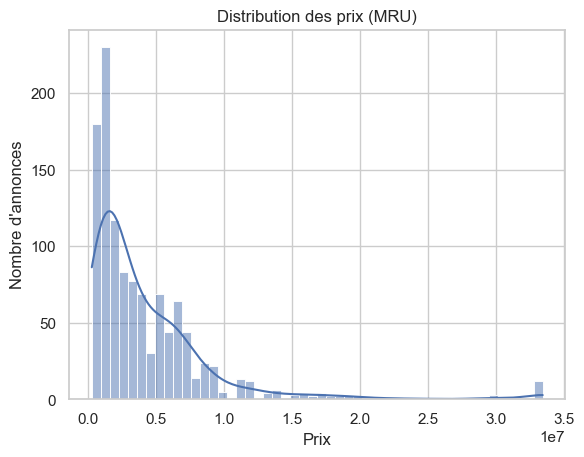

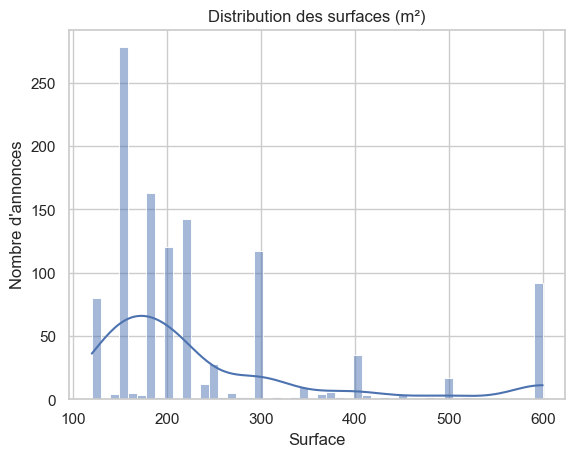

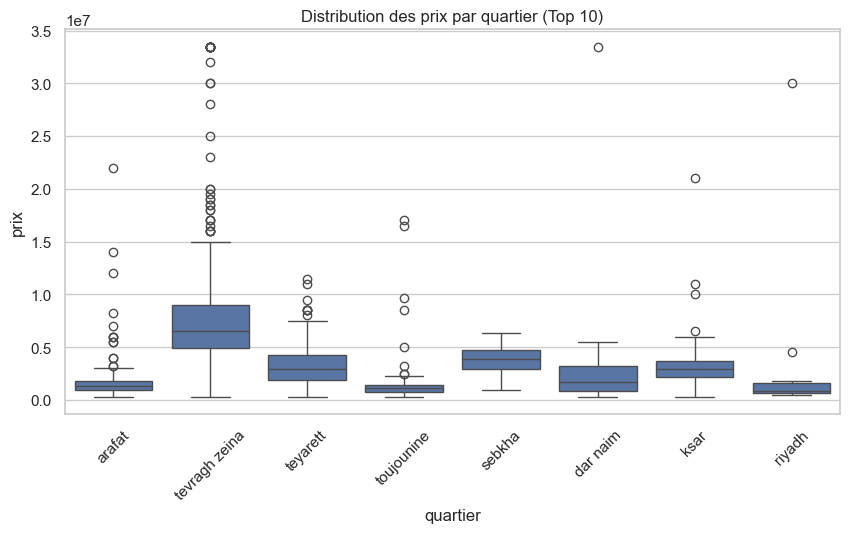

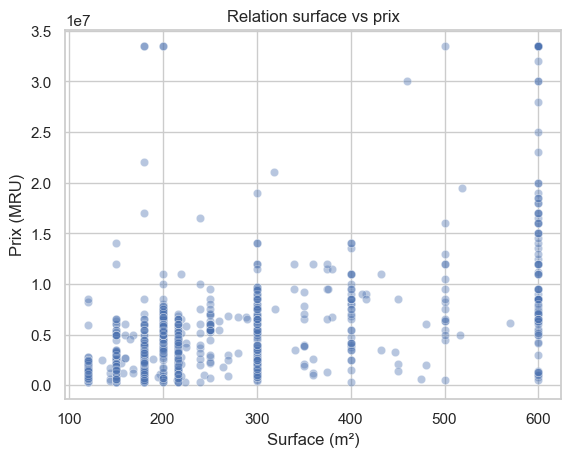

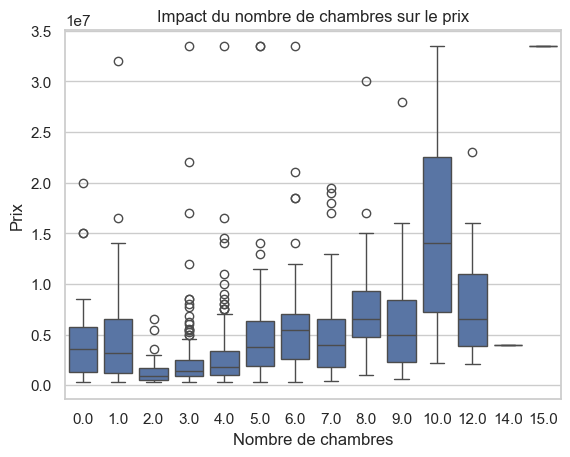

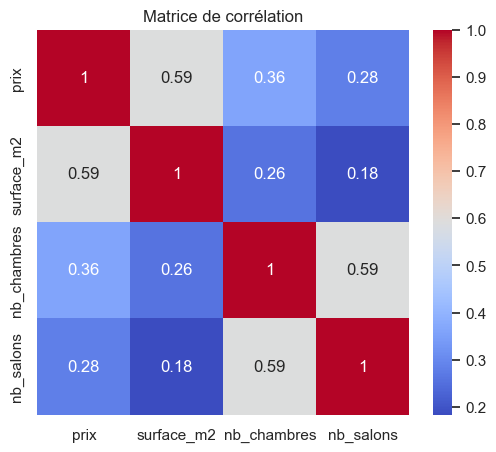

Pas de coordonnées géographiques → PCA ignorée


In [6]:
# =========================================
# Etapes 5-7 - Analyses Uni / Bi / Multivariées
# =========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# Style simple
sns.set(style="whitegrid")
# ----- 1. Charger le dataset train -----
train = pd.read_csv("train_cleaned.csv")
# =========================================
# ETAPE 5 - ANALYSE UNIVARIÉE
# =========================================
# ---- Distribution du prix ----
plt.figure()
sns.histplot(train['prix'], bins=50, kde=True)
plt.title("Distribution des prix (MRU)")
plt.xlabel("Prix")
plt.ylabel("Nombre d'annonces")
plt.show()
# ---- Distribution de la surface ----
plt.figure()
sns.histplot(train['surface_m2'], bins=50, kde=True)
plt.title("Distribution des surfaces (m²)")
plt.xlabel("Surface")
plt.ylabel("Nombre d'annonces")
plt.show()
# =========================================
# ETAPE 6 - ANALYSE BIVARIÉE
# =========================================
# ---- Prix par quartier (top 10 quartiers) ----
top_quartiers = train['quartier'].value_counts().head(10).index
plt.figure(figsize=(10,5))
sns.boxplot(
    data=train[train['quartier'].isin(top_quartiers)],
    x='quartier',
    y='prix'
)
plt.xticks(rotation=45)
plt.title("Distribution des prix par quartier (Top 10)")
plt.show()
# ---- Corrélation surface / prix ----
plt.figure()
sns.scatterplot(
    data=train,
    x='surface_m2',
    y='prix',
    alpha=0.4
)
plt.title("Relation surface vs prix")
plt.xlabel("Surface (m²)")
plt.ylabel("Prix (MRU)")
plt.show()
# ---- Impact du nombre de chambres ----
plt.figure()
sns.boxplot(
    data=train,
    x='nb_chambres',
    y='prix'
)
plt.title("Impact du nombre de chambres sur le prix")
plt.xlabel("Nombre de chambres")
plt.ylabel("Prix")
plt.show()
# =========================================
# ETAPE 7 - ANALYSE MULTIVARIÉE
# =========================================
# ---- Matrice de corrélation ----
num_cols = ['prix', 'surface_m2', 'nb_chambres', 'nb_salons']
corr = train[num_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()
# =========================================
# PCA sur les features géographiques
# (si latitude / longitude existent)
# =========================================
geo_cols = ['latitude', 'longitude']
if all(col in train.columns for col in geo_cols):
    scaler = StandardScaler()
    geo_scaled = scaler.fit_transform(train[geo_cols])
    pca = PCA(n_components=2)
    geo_pca = pca.fit_transform(geo_scaled)
    train['geo_pca_1'] = geo_pca[:, 0]
    train['geo_pca_2'] = geo_pca[:, 1]
    plt.figure()
    sns.scatterplot(
        x=train['geo_pca_1'],
        y=train['geo_pca_2'],
        alpha=0.5
    )
    plt.title("PCA - composantes géographiques")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()
    print("Variance expliquée par PCA :", pca.explained_variance_ratio_)
else:
    print("Pas de coordonnées géographiques → PCA ignorée")


In [7]:
# =========================================
# Etape 8 - Preparation (Encoding + log(prix))
# =========================================
import pandas as pd
import numpy as np
# ----- 1. Charger datasets -----
train = pd.read_csv("train_cleaned.csv")
test = pd.read_csv("test_cleaned.csv")
# =========================================
# 2. Target Encoding pour 'quartier'
# =========================================
# Calculer moyenne du prix par quartier sur le train
quartier_mean = train.groupby('quartier')['prix'].mean().to_dict()
# Fonction pour encoder
def encode_quartier(x):
    return quartier_mean.get(x, train['prix'].mean())  # Si quartier absent dans test, mettre moyenne globale
# Appliquer sur train et test
train['quartier_encoded'] = train['quartier'].apply(encode_quartier)
test['quartier_encoded'] = test['quartier'].apply(encode_quartier)
print("=== Quartiers encodés avec Target Encoding ===")
# =========================================
# 3. Log-transform du prix
# =========================================
train['log_prix'] = np.log1p(train['prix'])
print("=== Log-transform appliqué sur le prix ===")
# =========================================
# 4. Split train/test pour modèle
# (facultatif : pour validation locale)
# =========================================
from sklearn.model_selection import train_test_split
X = train.drop(columns=['prix', 'log_prix'])  # Features
y = train['log_prix']  # Target
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}")
# =========================================
# 5. Sauvegarde des datasets préparés
# =========================================
train.to_csv("train_prepared.csv", index=False)
test.to_csv("test_prepared.csv", index=False)
print("\n=== Etape 8 terminée : datasets prêts pour ML ===")

=== Quartiers encodés avec Target Encoding ===
=== Log-transform appliqué sur le prix ===
Train shape: (922, 13), Validation shape: (231, 13)

=== Etape 8 terminée : datasets prêts pour ML ===
